In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import numpy as np

## 1. Load data from csv

In [14]:
file_sizes_mapping = {
    'achromobacter_xylosoxidans__01.asm.tar.xz': 34262084,
    'achromobacter_xylosoxidans__01.seq': 1900003732,
    'achromobacter_xylosoxidans__01_1_16.seq': 118750233,
    'achromobacter_xylosoxidans__01_1_4.seq': 475000933,
    'achromobacter_xylosoxidans__01_1_64.seq': 29687558,
    'escherichia_coli__01.seq': 20107289519,
    'escherichia_coli__01_1_16.seq': 1256705594,
    'escherichia_coli__01_1_4.seq': 5026822379,
    'escherichia_coli__01_1_64.seq': 314176398,
    'listeria_monocytogenes__01.seq': 11895061336,
    'listeria_monocytogenes__01_1_16.seq': 743441333,
    'listeria_monocytogenes__01_1_4.seq': 2973765334,
    'listeria_monocytogenes__01_1_64.seq': 185860333,
    'mycobacterium_tuberculosis__01.seq': 17431192636,
    'mycobacterium_tuberculosis__01_1_16.seq': 1089449539,
    'mycobacterium_tuberculosis__01_1_4.seq': 4357798159,
    'mycobacterium_tuberculosis__01_1_64.seq': 272362384,
    'streptococcus_pneumoniae__01.seq': 8323738202,
    'streptococcus_pneumoniae__01_1_16.seq': 520233637,
    'streptococcus_pneumoniae__01_1_4.seq': 2080934550,
    'streptococcus_pneumoniae__01_1_64.seq': 130058409
}

df_linux = pd.read_csv('../results/exp2_linux.csv')
df_linux['os'] = 'linux'

df_windows = pd.read_csv('../results/exp2_windows.csv')
df_windows['os'] = 'windows'

df = pd.concat([df_linux, df_windows], ignore_index=True)

# Remove not correct configurations
df = df[df['is_correct'] == 1]

## 2. Plot compression ratio vs. file size chart for each compressor

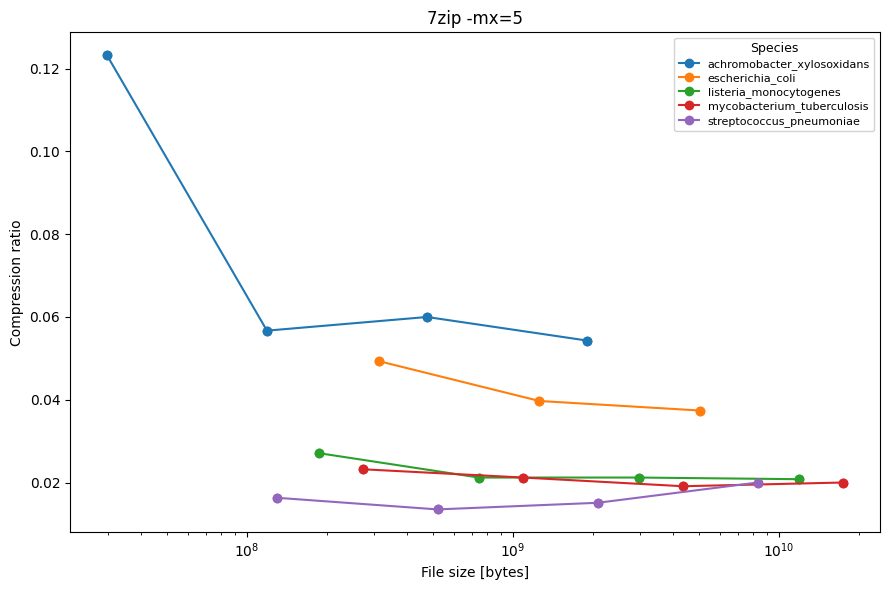

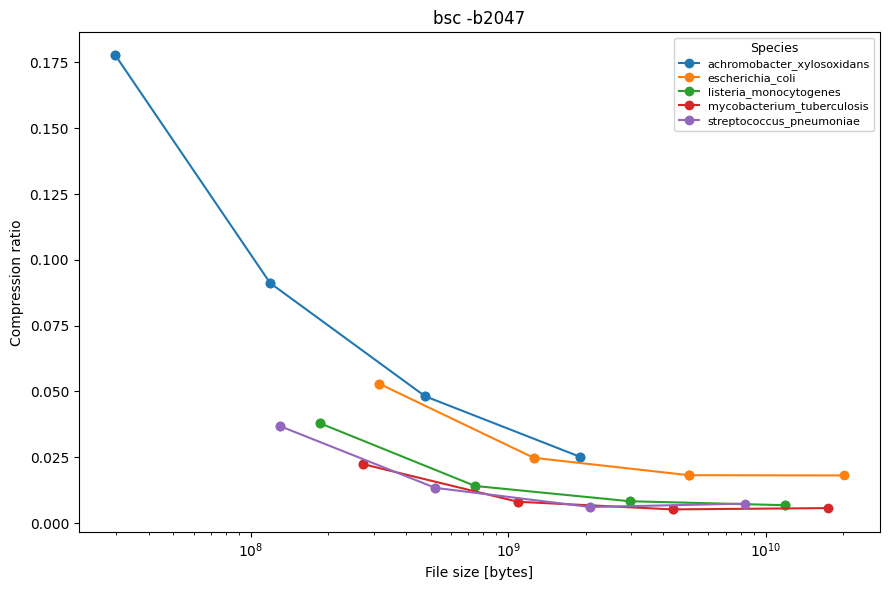

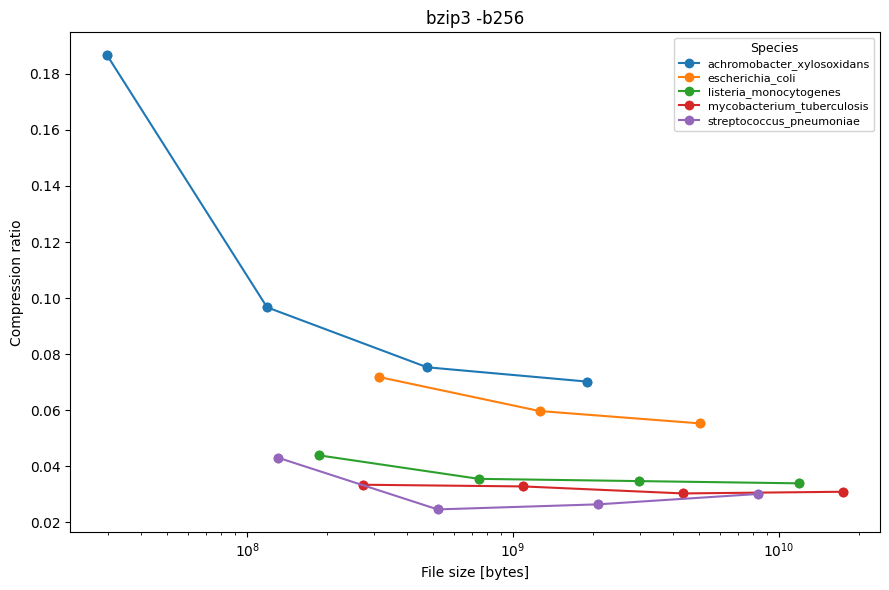

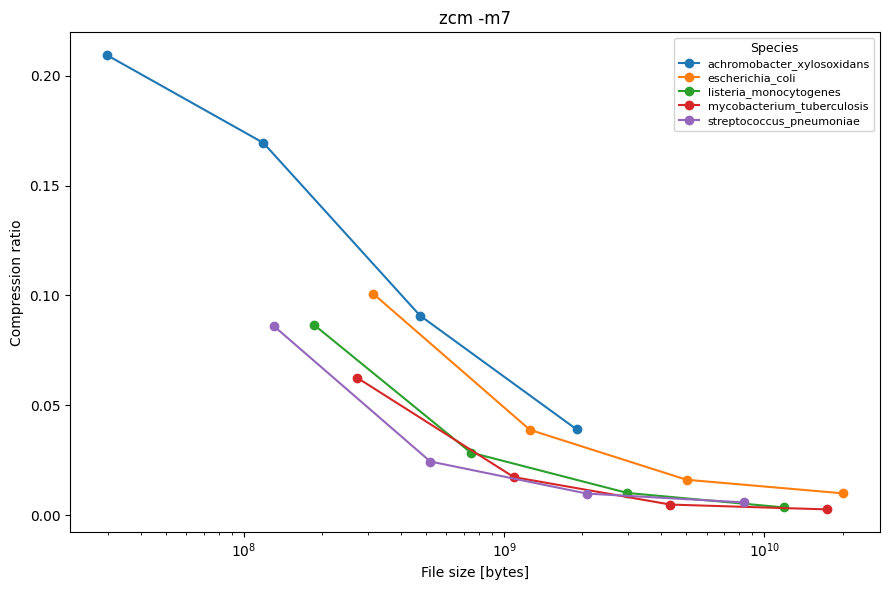

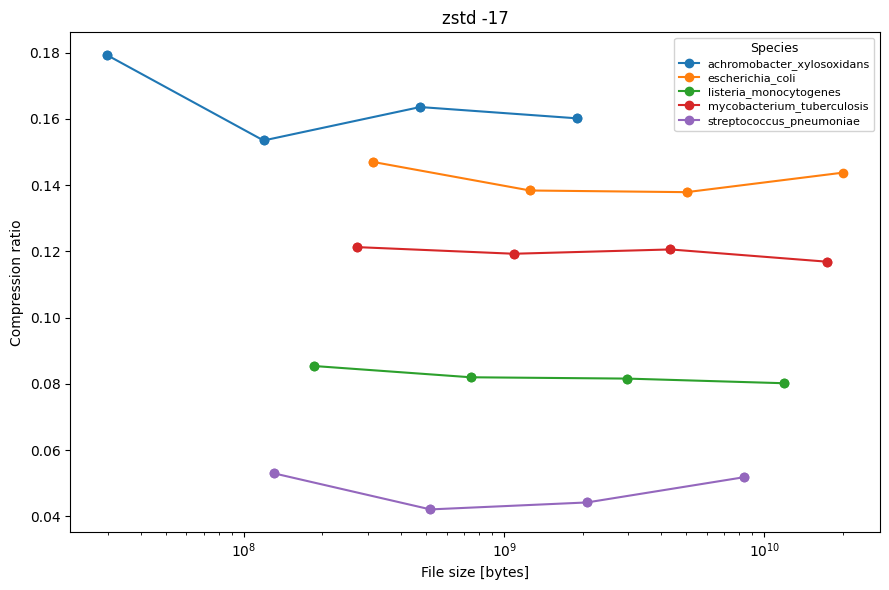

In [33]:
def get_species(filename):
    # e.g. 'achromobacter_xylosoxidans__01_1_16.seq' -> 'achromobacter_xylosoxidans'
    return filename.split('__')[0]

df['species'] = df['file'].apply(get_species)
df['file_size'] = df['file'].map(file_sizes_mapping)

species_list = sorted(df['species'].unique())
compressors = sorted(df['compressor'].unique())

cmap = plt.get_cmap('tab10')
species_colors = {sp: cmap(i % 10) for i, sp in enumerate(species_list)}

os_markers = {'linux': 'o', 'windows': 's'}
os_linestyles = {'linux': '-', 'windows': '--'}

os.makedirs('plots', exist_ok=True)

for comp in compressors:
    fig, ax = plt.subplots(figsize=(9, 6))
    sub = df[df['compressor'] == comp]

    for sp in species_list:
        sp_data = sub[sub['species'] == sp].sort_values('file_size')
        if sp_data.empty:
            continue
        ax.plot(
            sp_data['file_size'], sp_data['compression_ratio'],
            marker='o', linestyle='-', color=species_colors[sp]
        )

    ax.set_xscale('log')
    ax.set_xlabel('File size [bytes]')
    ax.set_ylabel('Compression ratio')
    ax.set_title(comp)

    legend_elements = [
        Line2D([0], [0], marker='o', color=species_colors[sp], label=sp, linestyle='-')
        for sp in species_list
    ]
    ax.legend(
        handles=legend_elements,
        title='Species',
        loc='upper right',
        fontsize=8,
        title_fontsize=9,
        framealpha=0.85,
        borderpad=0.4,
        labelspacing=0.3,
        handlelength=1.8,
    )

    fname = comp.replace(' ', '_').replace('=', '')
    plt.tight_layout()
    plt.savefig(os.path.join('plots', f'ratio_{fname}.svg'))
    plt.show()


## 3. Plot compression time vs. file size chart for each compressor

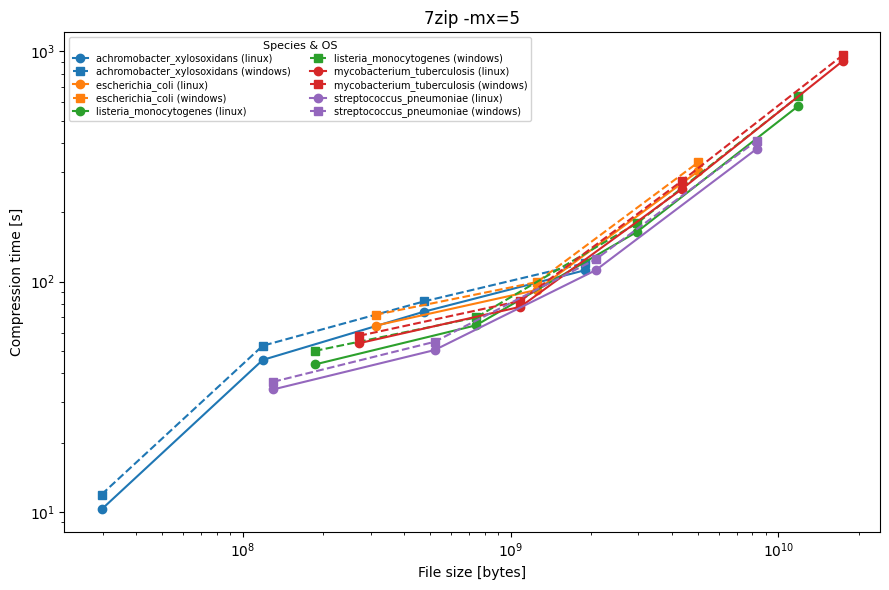

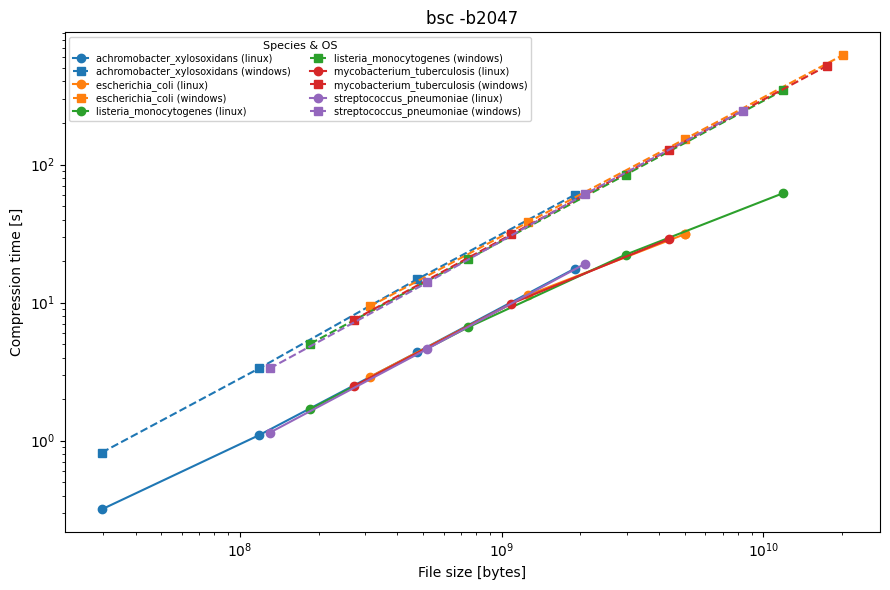

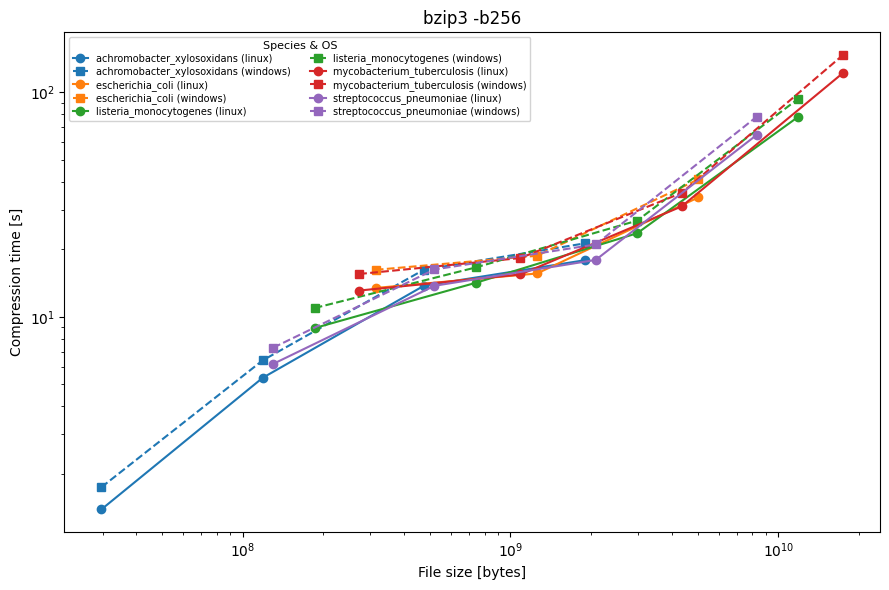

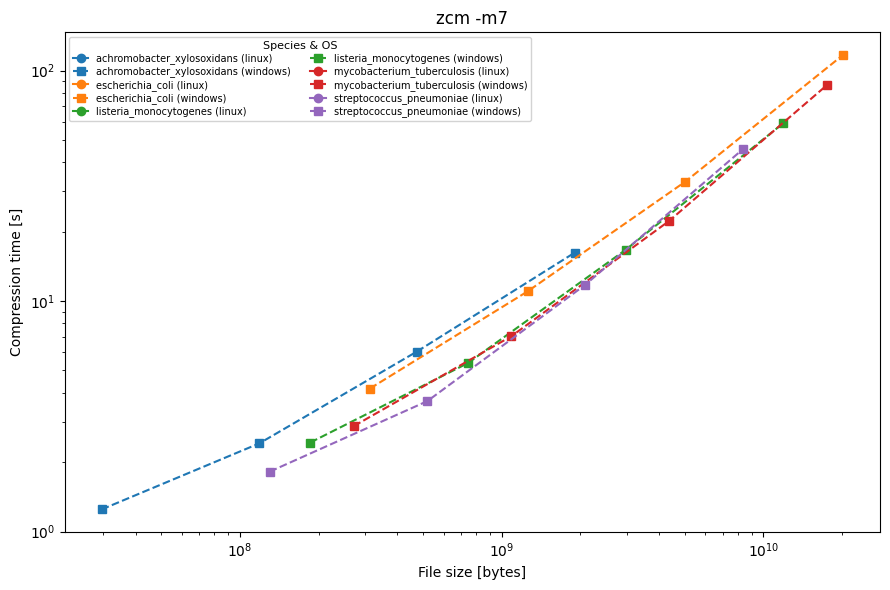

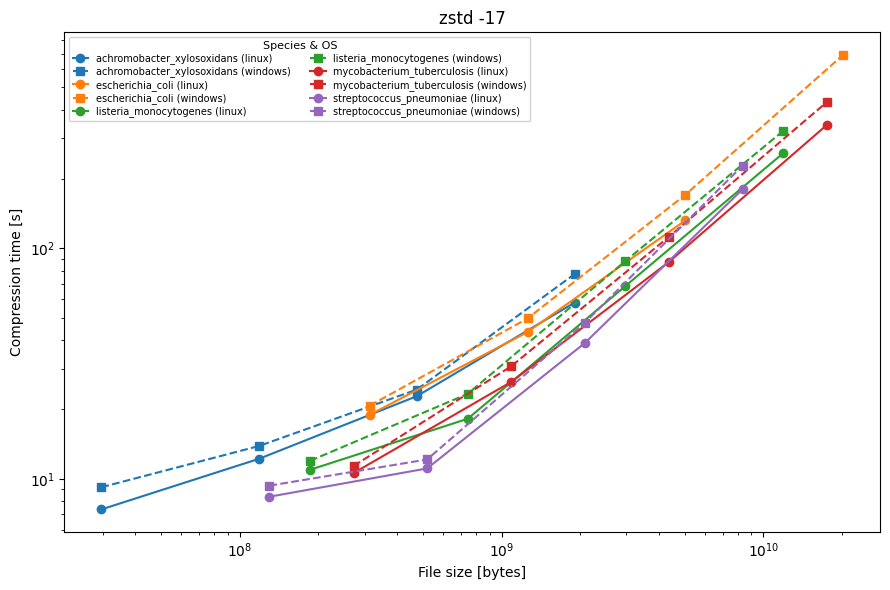

In [32]:
for comp in compressors:
    fig, ax = plt.subplots(figsize=(9, 6))
    sub = df[df['compressor'] == comp]

    for sp in species_list:
        for os_name in ['linux', 'windows']:
            sp_os_data = sub[(sub['species'] == sp) & (sub['os'] == os_name)].sort_values('file_size')
            if sp_os_data.empty:
                continue
            ax.plot(
                sp_os_data['file_size'], sp_os_data['compression_time'],
                marker=os_markers[os_name], linestyle=os_linestyles[os_name],
                color=species_colors[sp]
            )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('File size [bytes]')
    ax.set_ylabel('Compression time [s]')
    ax.set_title(f'{comp}')

    legend_elements = [
        Line2D(
            [0], [0],
            marker=os_markers[os_name],
            color=species_colors[sp],
            label=f'{sp} ({os_name})',
            linestyle=os_linestyles[os_name]
        )
        for sp in species_list for os_name in ['linux', 'windows']
    ]
    ax.legend(
        handles=legend_elements,
        title='Species & OS',
        loc='upper left',
        fontsize=7,
        title_fontsize=8,
        framealpha=0.85,
        borderpad=0.35,
        labelspacing=0.25,
        handlelength=1.6,
        ncol=2,
    )

    fname = comp.replace(' ', '_').replace('=', '')
    plt.tight_layout()
    plt.savefig(os.path.join('plots', f'time_{fname}.svg'))
    plt.show()
